# 90819-Python Final Project: Polluter Proximity and Home Values

## Project Description
Our primary research question is: How has proximity to major industrial polluters shaped home values, vacancy, and housing distress in Mon Valley municipalities, compared with the rest of Allegheny County?

Pittsburgh consistently ranks as one of the worst polluted areas in the United States. Allegheny county in particular, ranks as one of the worst, ranking 23 in the US in 2026 (https://www.lung.org/research/sota/key-findings/most-polluted-places). Industrial polluters can cause major adverse health effects due to the release of harmful particles into the air, such as benzene, lead and lead compounds, mercury and mercury compounds, methanol, and nitrates. We want to see if these adverse health due to industrial polluters have any affect on where people choose to live. We proxy this by home values; i.e., do people with the higher incomes, more education, etc, have higher value homes, and are these homes further away from major industrial polluters.

### Set-up
Install necessary libraries and load necessary packages then read in and describe data.

In [15]:
# install libraries
# %pip install seaborn
# %pip install geopandas
# %pip install census
# %pip install pandas
# %pip install us
# %pip install pytidycensus

In [16]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pytidycensus as tc
from dotenv import load_dotenv
import os
from pathlib import Path


In [17]:
# READ IN DATA
# Allegheny County property assessments dataframe
assessments_df = pd.read_csv("property_assessments.csv")
# Allegheny County municipalities dataframe
municipalities_df = pd.read_csv("allegheny_municipalities.csv")
# Allegheny County parcel boundaries
parcel_boundaries_df = pd.read_csv("allegheny_parcel_boundaries.csv")
# Allegheny County municipal boundaries geopandas dataframe
municipal_boundaries_gdf = gpd.read_file("allegheny_municipal_boundaries.geojson")

/var/folders/92/rrvsc6_x7slf490khsx_xn2c0000gn/T/ipykernel_59399/3229317460.py:3: DtypeWarning: Columns (19,20,29,30,31,37,38,57,83) have mixed types. Specify dtype option on import or set low_memory=False.
  assessments_df = pd.read_csv("property_assessments.csv")


In [18]:
print(assessments_df.columns.tolist())
display(assessments_df.head())

# print(parcel_boundaries_df.shape)
# display(parcel_boundaries_df.head())

# print(municipal_boundaries_gdf.shape)
# display(municipal_boundaries_gdf.head())

(586983, 10)


,_id,pin,map_block_lot,municode,calc_acreage,comments,notes,pseudono,shape_length,wkt
0,11149546,0102P00193000000,102-P-193,941,0.07,,,,306.498674,"POLYGON ((1315443.201163441 395608.8254300803,..."
1,11149547,0124F00169000000,124-F-169,112,0.02,,,,149.703009,POLYGON ((1367397.8283080012 420679.9277930259...
2,11149548,0006K00358000000,6-K-358,119,0.04,,,,235.746576,POLYGON ((1335443.7571371496 409727.6951995492...
3,11149549,0858M00274000000,858-M-274,879,0.25,,,,430.870823,POLYGON ((1411227.8753697425 401626.7493780404...
4,11149550,0407J00004000000,407-J-4,946,0.83,,,9946X01562000000,1260.436214,POLYGON ((1292132.9464045465 397263.8131626844...


The property assessments data contains 585,005 rows and 86 columns. The primary columns that we need are the: 
- PARID (parcel ID)
- PROPERTYCITY (city where the property is located)
- CLASSDESC (building class (description))
- GRADE (dwelling grade)
- GRADEDESC (dwelling grade description)
- OWNERDESC (owner description)
- SALEDATE (sale date)
- SALEPRICE (sale price)
- COUNTYBUILDING (county assessed value for building)
- COUNTYLAND (county assessed value for land)
- COUNTYTOTAL (county assessed value)
- FAIRMARKETBUILDING (county assessed fair market building value)
- FAIRMARKETLAND (county assessed fair market land value)
- FAIRMARKETTOTAL (county assessed fair market total value)
- TAXYEAR (current certified tax year)

### Clean Up Data
Subset the assessments dataframe. Join the parcel boundaries to the assessments by parcel ID.

In [19]:
# subset assessments to relevant columns
assessments_clean_df = assessments_df[[ 
    "PARID",
    "PROPERTYCITY",
    "CLASS",
    "CLASSDESC",
    "OWNERDESC",
    "GRADE",
    "SALEDATE",
    "SALEPRICE",
    "COUNTYBUILDING",
    "COUNTYLAND",
    "COUNTYTOTAL",
    "FAIRMARKETBUILDING",
    "FAIRMARKETLAND",
    "FAIRMARKETTOTAL",
    "TAXYEAR"
]].rename(columns=str.lower).copy()

# subset municipal boundaries to relevant columns
municipal_boundaries_clean_gdf = municipal_boundaries_gdf[[
    "NAME",
    "TYPE",
    "REGION",
    "SQMI",
    "EOC",
    "geometry"
]].rename(columns=str.lower).copy()

# separate saledate column into day, month, and year
assessments_clean_df[["sale_day", "sale_month", "sale_year"]] = assessments_clean_df["saledate"].str.split("-", expand=True)

# convert day, month, and year columns to integers
def change_to_int(df):
    return df.apply(pd.to_numeric, errors="coerce").astype("Int64")

assessments_clean_df[["sale_day", "sale_month", "sale_year"]] = change_to_int(
    assessments_clean_df[["sale_day", "sale_month", "sale_year"]]
)

        # assessments_clean_df["sale_day"] = assessments_clean_df["sale_day"].astype(int)
        # assessments_clean_df["sale_month"] = assessments_clean_df["sale_month"].astype(int)
        # assessments_clean_df["sale_year"] = assessments_clean_df["sale_year"].astype(int)

# rename pin to parid in parcels dataframe
parcel_boundaries_clean = parcel_boundaries_df.rename(columns={"pin":"parid", "wkt":"geometry"}).copy()

# join assessments and parcel boundaries on parid
assessment_parcel_df = assessments_clean_df.merge(parcel_boundaries_clean, on="parid", how="left")

# set assessment parcel dataframe as a geopandas dataframe
assessment_parcel_df = gpd.GeoDataFrame(
    assessment_parcel_df,
    geometry=gpd.GeoSeries.from_wkt(assessment_parcel_df["geometry"]),
    crs="EPSG:2272"  # PA South State Plane (US feet)
)

# set municipal_boundaries_clean_gdf coordinate system to match assessment_parcel_df coordinate system
municipal_boundaries_clean_gdf = municipal_boundaries_clean_gdf.to_crs(assessment_parcel_df.crs)

assessment_parcel_df["centroid"] = assessment_parcel_df.geometry.centroid
assessment_parcel_df = assessment_parcel_df.rename(columns={"geometry":"polygeom"})
assessment_parcel_df = assessment_parcel_df.set_geometry("centroid")

# apply spatial join of assessment parcel dataframe with municipal boundaries
assessment_parcel_municipal_df = gpd.sjoin(
    assessment_parcel_df,
    municipal_boundaries_clean_gdf,
    how="left",
    predicate="intersects"
)

# reset geometry back to polygeom
assessment_parcel_municipal_df = assessment_parcel_municipal_df.set_geometry("polygeom")

There should be 585,005 rows in the dataframe after the spatial join. If there is a discrepancy the join is wrong.

In [ ]:
# view merged dataframe
assessment_parcel_municipal_df.describe

Index(['parid', 'propertycity', 'class', 'classdesc', 'ownerdesc', 'saledate',
       'saleprice', 'countybuilding', 'countyland', 'countytotal',
       'fairmarketbuilding', 'fairmarketland', 'fairmarkettotal', 'taxyear',
       'sale_day', 'sale_month', 'sale_year', '_id', 'map_block_lot',
       'municode', 'calc_acreage', 'comments', 'notes', 'pseudono',
       'shape_length', 'polygeom', 'centroid', 'index_right', 'name', 'type',
       'region', 'sqmi', 'eoc'],
      dtype='object')

In [ ]:
# export assessment_parcel_municipal_df
parcel_df_analytical=(
    # convert centroid geometry to lat/lon columns
    assessment_parcel_municipal_df
    .assign(
        centroid_4326=lambda x: x["centroid"].to_crs("EPSG:4326"),
        lat=lambda x: x["centroid_4326"].y.astype("string"),
        lon=lambda x: x["centroid_4326"].x.astype("string")
    )
    .drop(columns = ["centroid", "centroid_4326"])
)

parcel_df_analytical.to_file("assessor_parcels_analytic.geojson", driver="GeoJSON")

## Preliminary Analysis
Exploring the parcels data

Top 3 parcel uses by class: 
1. RESIDENTIAL (523754)
2. COMMERCIAL (35870)
3. GOVERNMENT (16881)
Top 3 parcel uses by class in 2024: 
1. RESIDENTIAL (24161)
2. COMMERCIAL (1419)
3. INDUSTRIAL (142)


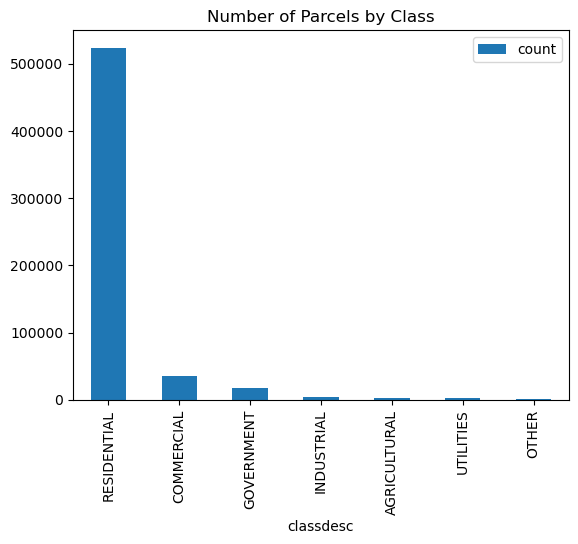

In [10]:
# get number of buildings by class
buildings_by_class = (assessment_parcel_municipal_df
                      .groupby("classdesc")
                      .size()
                      .reset_index(name="count")
                      .sort_values(by="count", ascending=False))

buildings_by_class.plot.bar(x="classdesc", y="count", title="Number of Parcels by Class")

print(f"Top 3 parcel uses by class: \n1. {buildings_by_class.iloc[0]['classdesc']} ({buildings_by_class.iloc[0]['count']})\n2. {buildings_by_class.iloc[1]['classdesc']} ({buildings_by_class.iloc[1]['count']})\n3. {buildings_by_class.iloc[2]['classdesc']} ({buildings_by_class.iloc[2]['count']})")

# filter to the year 2024 and check again
assessment_parcel_2024_df = assessment_parcel_municipal_df[assessment_parcel_municipal_df["sale_year"]==2024]
buildings_by_class_2024 = (assessment_parcel_2024_df
                           .groupby("classdesc")
                           .size()
                           .reset_index(name="count")
                           .sort_values(by="count", ascending=False))

print(f"Top 3 parcel uses by class in 2024: \n1. {buildings_by_class_2024.iloc[0]['classdesc']} ({buildings_by_class_2024.iloc[0]['count']})\n2. {buildings_by_class_2024.iloc[1]['classdesc']} ({buildings_by_class_2024.iloc[1]['count']})\n3. {buildings_by_class_2024.iloc[2]['classdesc']} ({buildings_by_class_2024.iloc[2]['count']})")
# print("We want to focus on residential properties for this analysis.")

The top 3 parcel uses in Allegheny county are Residential (523,754), Commercial (35,870), and Government (16,881). We filter to properties sold in 2024 to align home sale values with our census data and get 24,161 residential parcels, 1,419 commerical parcels, and 142 industrial parcels.

We want to focus on just residential home values in this analysis.

In [11]:
# Median residential sale value in 2024
median_residential_sale_value_2024 = (assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]
                                      .agg({"saleprice":["min","max","mean","median"]})
                                      .round(2)
                                      )
median_residential_sale_value_2024

,saleprice
min,0.00
max,14466000.00
mean,220892.47
median,150000.00


In [12]:
# Median residential sale value in 2024
median_residential_property_value_2024 = (assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]
                                          .agg({
                                              "countybuilding":["min","max","mean","median"],
                                              "countyland":["min","max","mean","median"],
                                              "countytotal":["min","max","mean","median"],
                                              "fairmarketbuilding":["min","max","mean","median"],
                                              "fairmarketland":["min","max","mean","median"],
                                              "fairmarkettotal":["min","max","mean","median"]
                                              }).round(2))
median_residential_property_value_2024


,countybuilding,countyland,countytotal,fairmarketbuilding,fairmarketland,fairmarkettotal
min,0.0,0.00,0.00,0.00,0.00,0.00
max,4003800.0,1145200.00,4250000.00,4003800.00,1145200.00,4250000.00
mean,99214.5,30866.01,130080.51,106865.74,31056.01,137921.75
median,67100.0,23400.00,94600.00,75900.00,23500.00,103300.00


County assessment values are generally less than fair market assessment values for both the building and land values.

In [13]:
# parcels by municipality
parcels_by_municipality = (assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]
                           .groupby("name")["parid"]
                           .count()
                           .reset_index(name="parcels")
                           .sort_values(by="parcels", ascending=False)
                           )

## Regression Model
We will model two primary regressions:
- Residential parcel values (sale prices) by average distance to a polluter
    - Covariates will include median household income, vacancy rates, share white, college educated share, dwelling grade
    - Null hypothesis: proximity to major industrial polluters has no effect on home values
- Census tract level vacancy rates by average distance to a polluter
    - Covariates will include median household income, share white, college educated share, dwelling grade
    - Null hypothesis: proximity to major industrial polluters has no effect on vacancy rates

Our first model is as follows:
$$
\text{ResidentialSalePrice}_{i} = \beta_0
+
\beta_1 \,\text{MedianHouseholdIncome}_{i}
+
\beta_2 \,\text{VacancyRate}_{i}
+
\beta_3 \,\text{ShareWhite}_{i}
+
\beta_4 \,\text{ShareCollegeEducated}_{i}
+
\beta_5 \,\text{DwellingGrade}_{i}
+
\varepsilon_i
$$

And model 2 is: 
$$
\text{Vacancy Rate}_{i} = \beta_0
+
\beta_1 \,\text{MedianHouseholdIncome}_{i}
+
\beta_2 \,\text{ShareWhite}_{i}
+
\beta_3 \,\text{ShareCollegeEducated}_{i}
+
\beta_4 \,\text{DwellingGrade}_{i}
+
\varepsilon_i
$$

